# COSETTE & MARIUS: reproduction, audit, and the road to an extension

The whole project in one notebook: what the paper claims, what our reproduction found, the beyond-accuracy audit that surfaced a new phenomenon, the mechanism study that explains it, and the four intervention pilots with their final results. Every number is loaded from committed artifacts in this repo and every model number traces back to the authors' own unmodified evaluation code.

**The arc in five sentences.** (1) We reproduced arXiv:2508.14910 (COSETTE collaborative tokenizer + MARIUS RQ-Transformer recommender) on Beauty and Sports, found the repo's default baseline config differs from the paper's, fixed it, and still found the paper's 'competitive at small scale' claim does not hold: the tuned traditional baseline beats MARIUS. (2) Measuring beyond accuracy, we found the generative model's diversity profile INVERTS with the dataset: healthier than the baseline on Beauty, collapsed on Sports where it can never recommend ~61% of the catalog. (3) The mechanism: the beam prunes weak code-pair families at decode step 2; items lose to their prefix siblings (confirmed on a second codebook). (4) Decode-time pilots: consensus re-ranking gives a tunable accuracy-vs-reach dial; conformal calibration gives guarantees and an uncertainty signal; and a depth-100 crossover shows MARIUS's deep candidates BEAT the baseline, so the likelihood ordering is what wastes them. (5) The architectural alternative (un-summing the code fusion) changes nothing: the problem is decoding, not architecture.

| Section | Content |
|---|---|
| 1 | The paper and its claims |
| 2 | Reproduction: configs, gap, negative result |
| 3 | Beyond-accuracy audit: the inversion |
| 4 | REACH: the collapse mechanism (+ robustness) |
| 5 | MBR: the accuracy-vs-reach dial |
| 6 | Conformal: guarantees, uncertainty, and the depth crossover |
| 7 | FUSE: the architectural null |
| 8 | Synthesis: the paper this adds up to |

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / 'scripts' / 'extensions' / 'beyond_accuracy.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
from scripts.extensions import beyond_accuracy as ba
from scripts.extensions.compute_beyond_accuracy import load_support, load_model_recs

RES = REPO / 'reports' / 'results'
FAITH = REPO / 'reports' / 'paper_faithful_rerun'
EXT = REPO / 'reports' / 'extensions'
CATS = ['Beauty', 'Sports_and_Outdoors']
SHORT = {'Beauty': 'Beauty', 'Sports_and_Outdoors': 'Sports'}
COL = {'marius': '#d62728', 'sasrec': '#1f77b4'}
plt.rcParams['figure.dpi'] = 110

def jsonl_r10(path):
    rows = [json.loads(l) for l in Path(path).read_text().splitlines() if l.strip()]
    vals = [r['R@10'] for r in rows if r.get('status') == 'ok']
    return float(np.mean(vals)), float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0, len(vals)

# Paper Table 5 targets (test, %)
PAPER = {'Beauty': {'sasrec': 9.73, 'marius': 10.02},
         'Sports_and_Outdoors': {'sasrec': 6.44, 'marius': 6.72}}
print('repo:', REPO)

repo: /home/stas/Desktop/University/RECSYS/rec_sys_cosette_marius


## 1. The paper

*Closing the Performance Gap in Generative Recommenders with Collaborative Tokenization and Efficient Modeling* (Lepage, Mary, Picard; Criteo AI Lab; arXiv:2508.14910). Two contributions:

- **COSETTE**: items get 4-digit 'semantic ID' codes from an RQ-VAE over text embeddings, with an extra contrastive loss so co-consumed items get similar codes (collaborative + semantic).
- **MARIUS**: a lightweight generative recommender (borrowed from audio modeling): a Temporal Transformer reads the history (one fused token per item), a Depth Transformer writes the next item's 4 code digits autoregressively; beam search returns the top candidates.

Claims: much faster than prior generative models (TIGER); beats the strong traditional baseline SASRec++ at large scale; **competitive with it at small scale** (Table 5: e.g. Beauty R@10 10.02 vs 9.73). That last claim is the one our mandatory reproduction tests.

## 2. Reproduction (mandatory scope: Beauty + Sports, 5 seeds)

Three acts, all visible in the chart below:

1. **First pass lands 15-28% low.** Running the repo as released (SASRec++ d=128 + L2 normalization) gives Beauty R@10 8.24 vs the paper's 9.73.
2. **We found the config root cause.** The paper selects the baseline size PER DATASET (appendix Figure 11a: Beauty's best is d=32, no normalization); the repo ships only the default. The faithful config recovers about 55% of the Beauty gap (8.24 to 9.06). Undertraining, the data split, the eval code, batch size, and tokenizer quality were all positively ruled out; the residual is consistent with a validation-to-test generalization gap.
3. **The honest negative result.** MARIUS's config already matches the paper, yet the FAITHFUL baseline clearly beats it (9.06 vs 8.17 on Beauty). The paper's small-scale competitiveness claim does not reproduce. Nobody else has independently tested it (the paper is v1-only, unreviewed, 2-3 citations), so this negative result is itself a contribution, and the launch point for everything that follows.

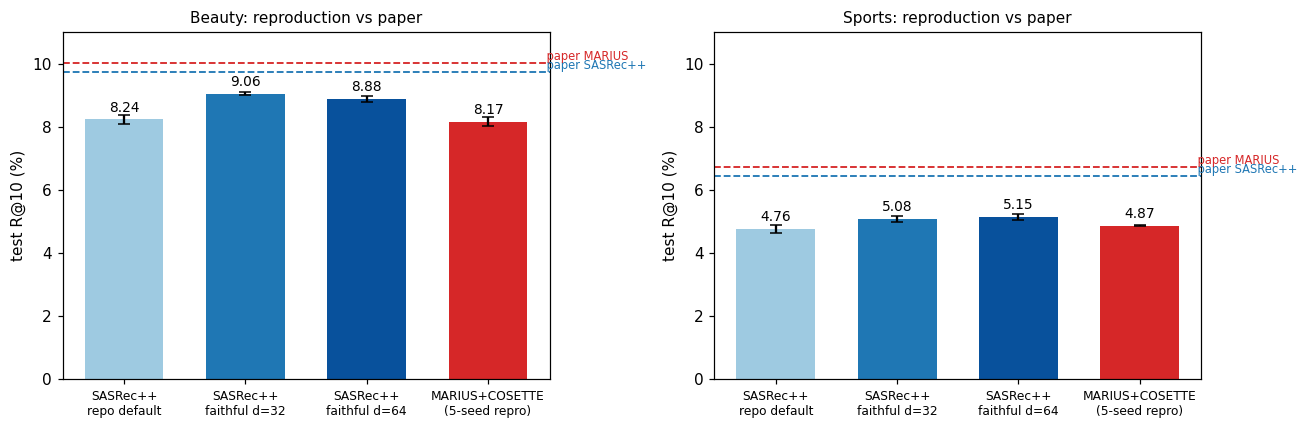

Beauty: faithful config recovers ~55% of the gap (8.24 -> 9.06 vs paper 9.73),
and faithful SASRec++ (9.06) beats MARIUS (8.17): the negative result.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cat, slug in zip(axes, CATS, ['beauty', 'sports']):
    bars = [
        ('SASRec++\nrepo default', jsonl_r10(RES / f'sasrec_{slug}_5seed_full_scores.jsonl'), '#9ecae1'),
        ('SASRec++\nfaithful d=32', jsonl_r10(FAITH / f'{slug}_d32__scores.jsonl'), COL['sasrec']),
        ('SASRec++\nfaithful d=64', jsonl_r10(FAITH / f'{slug}_d64__scores.jsonl'), '#08519c'),
        ('MARIUS+COSETTE\n(5-seed repro)', jsonl_r10(RES / f'marius_{slug}_5seed_full_scores.jsonl'), COL['marius']),
    ]
    x = np.arange(len(bars))
    for xi, (label, (mean, std, n), c) in zip(x, bars):
        ax.bar(xi, mean, 0.65, yerr=std, capsize=4, color=c)
        ax.text(xi, mean + 0.25, f'{mean:.2f}', ha='center', fontsize=9)
    ax.axhline(PAPER[cat]['sasrec'], color=COL['sasrec'], ls='--', lw=1.2)
    ax.axhline(PAPER[cat]['marius'], color=COL['marius'], ls='--', lw=1.2)
    ax.text(3.45, PAPER[cat]['sasrec'], ' paper SASRec++', fontsize=7.5, va='bottom', color=COL['sasrec'])
    ax.text(3.45, PAPER[cat]['marius'], ' paper MARIUS', fontsize=7.5, va='bottom', color=COL['marius'])
    ax.set_xticks(x); ax.set_xticklabels([b[0] for b in bars], fontsize=8)
    ax.set_ylabel('test R@10 (%)'); ax.set_title(f'{SHORT[cat]}: reproduction vs paper', fontsize=10)
    ax.set_ylim(0, 11)
plt.tight_layout(); plt.show()
print('Beauty: faithful config recovers ~55% of the gap (8.24 -> 9.06 vs paper 9.73),')
print('and faithful SASRec++ (9.06) beats MARIUS (8.17): the negative result.')

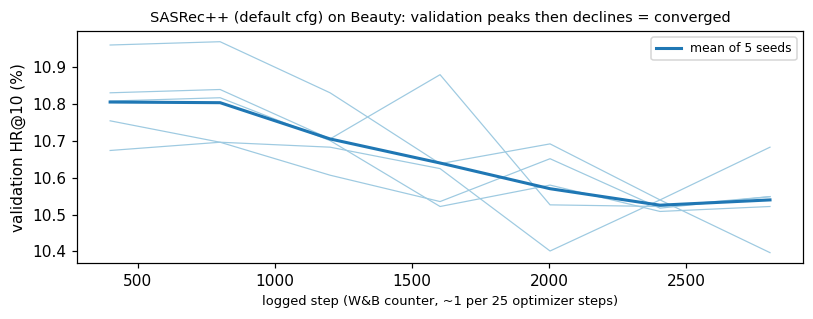

In [3]:
# Converged, not undertrained: validation HR@10 peaks early then declines.
fig, ax = plt.subplots(figsize=(7.5, 3))
frames = []
for seed in [42, 43, 44, 45, 46]:
    f = REPO / 'reports' / 'metrics' / f'sasrec_Beauty_seed{seed}.csv'
    df = pd.read_csv(f)
    df = df[df.metric == 'HR@10']
    ax.plot(df.step, 100 * df.value, color='#9ecae1', lw=0.8)
    frames.append(df.set_index('step')['value'])
mean = 100 * pd.concat(frames, axis=1).mean(axis=1)
ax.plot(mean.index, mean.values, color=COL['sasrec'], lw=2, label='mean of 5 seeds')
ax.set_xlabel('logged step (W&B counter, ~1 per 25 optimizer steps)', fontsize=8.5)
ax.set_ylabel('validation HR@10 (%)')
ax.set_title('SASRec++ (default cfg) on Beauty: validation peaks then declines = converged', fontsize=9.5)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Beyond-accuracy audit: the inversion

The paper reports only accuracy (plus one informal popularity plot). We captured the actual top-10 lists both trained models produce for every test user (a read-only pass through the authors' own `search()`; validated by matching the official HR@10 to the decimal) and measured catalog **coverage**, **Gini** concentration, and the **popularity-decile exposure profile**.

Result: one architecture, two opposite behaviors. On Beauty MARIUS is the healthier model (less blockbuster exposure, more mid-tail). On the sparser Sports catalog it inverts: coverage collapses to 39% and concentration EXCEEDS the baseline. And on both datasets MARIUS's tail-recall is lower, so its apparent diversity is exposure reshuffling, not better tail accuracy.

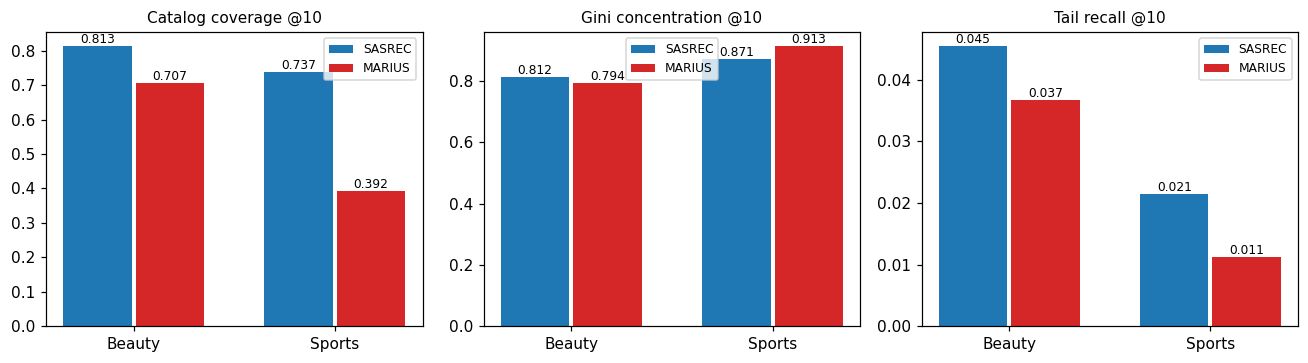

In [4]:
audit = pd.concat([pd.read_csv(EXT / f'beyond_accuracy_{c}.csv') for c in CATS])
a10 = audit[audit.k == 10].set_index(['category', 'model'])
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, metric, title in zip(
        axes, ['coverage_mean', 'gini_mean', 'tail_recall_mean'],
        ['Catalog coverage @10', 'Gini concentration @10', 'Tail recall @10']):
    x = np.arange(len(CATS))
    for i, m in enumerate(['sasrec', 'marius']):
        vals = [a10.loc[(c, m), metric] for c in CATS]
        ax.bar(x + (i - 0.5) * 0.36, vals, 0.34, label=m.upper(), color=COL[m])
        for xi, v in zip(x, vals):
            ax.text(xi + (i - 0.5) * 0.36, v, f'{v:.3f}'.rstrip('0'), ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels([SHORT[c] for c in CATS]); ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

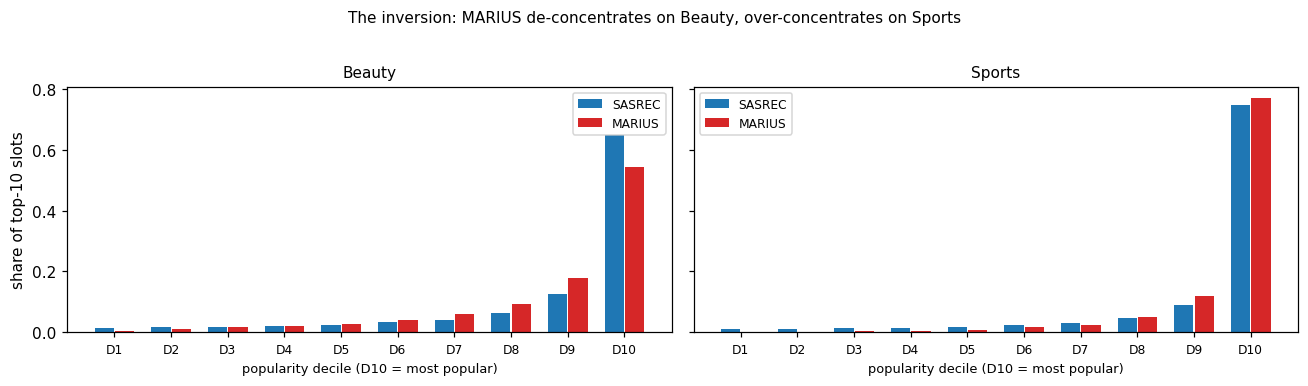

In [5]:
# Exposure profile: share of all top-10 slots per item-popularity decile.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
for ax, cat in zip(axes, CATS):
    meta, pop, _, t2i = load_support(EXT / 'topk' / cat)
    x = np.arange(10)
    for i, m in enumerate(['sasrec', 'marius']):
        profs = [ba.popularity_decile_exposure(load_model_recs(EXT / 'topk' / cat, m, s, meta, t2i)[0], pop, k=10)
                 for s in [42, 43, 44]]
        ax.bar(x + (i - 0.5) * 0.36, np.mean(profs, axis=0), 0.34, label=m.upper(), color=COL[m])
    ax.set_xticks(x); ax.set_xticklabels([f'D{i+1}' for i in range(10)], fontsize=8)
    ax.set_xlabel('popularity decile (D10 = most popular)', fontsize=8.5)
    ax.set_title(f'{SHORT[cat]}', fontsize=10); ax.legend(fontsize=8)
axes[0].set_ylabel('share of top-10 slots')
plt.suptitle('The inversion: MARIUS de-concentrates on Beauty, over-concentrates on Sports', fontsize=10, y=1.02)
plt.tight_layout(); plt.show()

## 4. REACH: why the collapse happens

A generative recommender can only recommend an item whose code it actually WRITES during beam search. We asked which items the beam can never write, and why.

- **Scale of the damage**: on Sports, 9,260 items (50% of the catalog) are never recommended by any seed; they carry **22% of all training demand** (the baseline's unreached set carries 5.7%).
- **Where it happens**: not at the first code digit (all 256 are used) but at digit 2: never-written (digit1, digit2) pairs cover 26% of the Sports catalog and account for half the unreachable items.
- **Why: sibling competition.** The best predictor of unreachability is an item's popularity share WITHIN its first-digit code family (r = -0.62), stronger than its own popularity (-0.58). Items lose to stronger siblings sharing their prefix.
- **Robustness**: a second, freshly trained Sports codebook reproduces all of it within 1-2 points; the collapse is structural, not a tokenizer-run artifact.

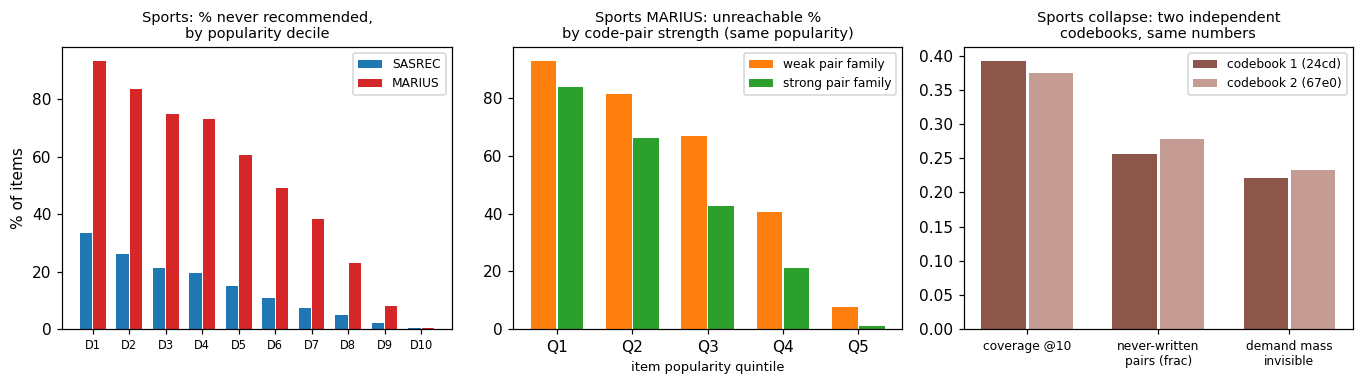

Mid-popularity (Q3) Sports items: 67% unreachable in weak pair families vs 43% in strong.
Sibling competition at decode step 2, robust across codebooks.


In [6]:
reach = {c: json.loads((EXT / 'reach' / f'reach_results_{c}.json').read_text()) for c in CATS}
cb2 = json.loads((EXT / 'reach_cb2' / 'reach_results_Sports_and_Outdoors.json').read_text())
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
# (a) unreachable by popularity decile, Sports
rows = reach['Sports_and_Outdoors']['structure']['decile_rows']
x = np.arange(10)
for i, m in enumerate(['sasrec', 'marius']):
    axes[0].bar(x + (i - 0.5) * 0.36, [100 * r[f'{m}_unreached_frac'] for r in rows], 0.34,
                label=m.upper(), color=COL[m])
axes[0].set_xticks(x); axes[0].set_xticklabels([f'D{r["decile"]}' for r in rows], fontsize=7.5)
axes[0].set_title('Sports: % never recommended,\nby popularity decile', fontsize=9.5)
axes[0].set_ylabel('% of items'); axes[0].legend(fontsize=8)
# (b) the mechanism: same-popularity items, weak vs strong code-pair family
t = reach['Sports_and_Outdoors']['mechanism']['table_l12']
xq = np.arange(5)
axes[1].bar(xq - 0.18, [100 * r['unreached_low'] for r in t], 0.34, label='weak pair family', color='#ff7f0e')
axes[1].bar(xq + 0.18, [100 * r['unreached_high'] for r in t], 0.34, label='strong pair family', color='#2ca02c')
axes[1].set_xticks(xq); axes[1].set_xticklabels([f'Q{r["quintile"]}' for r in t])
axes[1].set_title('Sports MARIUS: unreachable %\nby code-pair strength (same popularity)', fontsize=9.5)
axes[1].set_xlabel('item popularity quintile', fontsize=8.5); axes[1].legend(fontsize=8)
# (c) robustness across codebooks
m1, m2 = reach['Sports_and_Outdoors'], cb2
vals = {
    'coverage @10': (m1['reach']['marius_k10']['mean_reached_frac'], m2['reach']['marius_k10']['mean_reached_frac']),
    'never-written\npairs (frac)': (m1['mechanism']['pair_never_emitted_frac'], m2['mechanism']['pair_never_emitted_frac']),
    'demand mass\ninvisible': (m1['structure']['demand_mass_share_unreached'], m2['structure']['demand_mass_share_unreached']),
}
xv = np.arange(3)
axes[2].bar(xv - 0.18, [v[0] for v in vals.values()], 0.34, label='codebook 1 (24cd)', color='#8c564b')
axes[2].bar(xv + 0.18, [v[1] for v in vals.values()], 0.34, label='codebook 2 (67e0)', color='#c49c94')
axes[2].set_xticks(xv); axes[2].set_xticklabels(list(vals.keys()), fontsize=8)
axes[2].set_title('Sports collapse: two independent\ncodebooks, same numbers', fontsize=9.5)
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
print('Mid-popularity (Q3) Sports items: 67% unreachable in weak pair families vs 43% in strong.')
print('Sibling competition at decode step 2, robust across codebooks.')

## 5. MBR: a tunable accuracy-vs-reach dial

First intervention: keep the model frozen, change only how the beam's candidates are RANKED. Minimum-Bayes-Risk re-ranking prefers candidates that agree with the model's other guesses (consensus via shared code prefixes), weighted by the model's own confidence (softmax of candidate log-probabilities at temperature tau).

The verdict from the depth-100 scored runs: MBR is **not an accuracy fix** (the beam order stays best on R@10), but it is a clean, serving-time **dial**: sliding tau trades a little accuracy for a lot of reach. On collapsed Sports, giving up 0.6pp of R@10 buys +13 points of coverage, a one-quarter drop in average recommendation popularity, and +32% tail recall (which improves at EVERY tau).

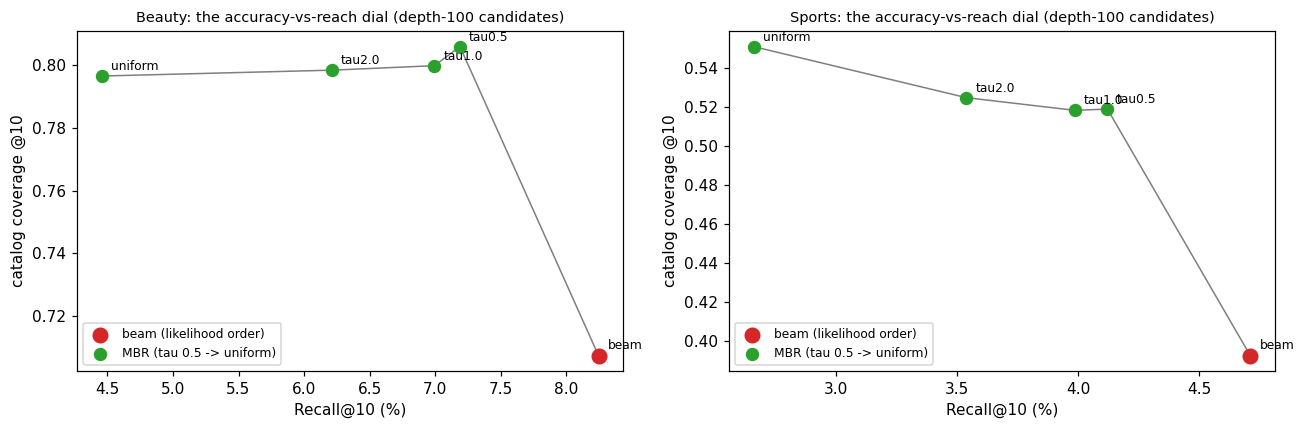

Sports, tau=0.5 vs beam: R@10 0.0471 -> 0.0412; coverage 0.39 -> 0.52; ARP 101 -> 73; tail-recall 0.0112 -> 0.0148 (+32%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cat in zip(axes, CATS):
    pts = {}
    for var in ['uniform', 'tau0.5', 'tau1.0', 'tau2.0']:
        df = pd.read_csv(EXT / 'mbr' / f'mbr_{cat}_d100_{var}.csv')
        m = df.groupby('variant')[['recall', 'coverage']].mean()
        pts['beam'] = m.loc['original']
        pts[var] = m.loc['mbr']
    order = ['beam', 'tau0.5', 'tau1.0', 'tau2.0', 'uniform']
    xs = [pts[p]['recall'] * 100 for p in order]
    ys = [pts[p]['coverage'] for p in order]
    ax.plot(xs, ys, '-', color='#7f7f7f', lw=1, zorder=1)
    ax.scatter(xs[0], ys[0], s=90, color=COL['marius'], zorder=3, label='beam (likelihood order)')
    ax.scatter(xs[1:], ys[1:], s=60, color='#2ca02c', zorder=3, label='MBR (tau 0.5 -> uniform)')
    for p, xpt, ypt in zip(order, xs, ys):
        ax.annotate(p, (xpt, ypt), textcoords='offset points', xytext=(6, 4), fontsize=8)
    ax.set_xlabel('Recall@10 (%)'); ax.set_ylabel('catalog coverage @10')
    ax.set_title(f'{SHORT[cat]}: the accuracy-vs-reach dial (depth-100 candidates)', fontsize=9.5)
    ax.legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()
sp = pd.read_csv(EXT / 'mbr' / 'mbr_Sports_and_Outdoors_d100_tau0.5.csv').groupby('variant')[['recall','coverage','arp','tail_recall']].mean()
print('Sports, tau=0.5 vs beam: R@10 {:.4f} -> {:.4f}; coverage {:.2f} -> {:.2f}; '
      'ARP {:.0f} -> {:.0f}; tail-recall {:.4f} -> {:.4f} (+32%)'.format(
      sp.loc['original','recall'], sp.loc['mbr','recall'], sp.loc['original','coverage'], sp.loc['mbr','coverage'],
      sp.loc['original','arp'], sp.loc['mbr','arp'], sp.loc['original','tail_recall'], sp.loc['mbr','tail_recall']))

## 6. Conformal: reliability, uncertainty, and the depth crossover

Second intervention: instead of a fixed top-10, return a SET calibrated to contain the true next item with a guaranteed frequency (distribution-free, split conformal on the target's rank). Honest finding: with one held-out item per user the guaranteeable coverage is capped by Recall@depth, so the realistic product is small sets with modest guarantees, plus a per-user **uncertainty meter**: calibrating separately per history-length bucket makes cold users get visibly larger sets (on Beauty, ~3.4x).

The unexpected discovery is in the left panel: at depth 20 the baseline has the higher ceiling, but **at depth 100 MARIUS overtakes it on both datasets**. MARIUS's deeper candidate pool is BETTER than the baseline's; its likelihood ordering of the top of the list is what wastes it. This independently corroborates the decoding-side story.

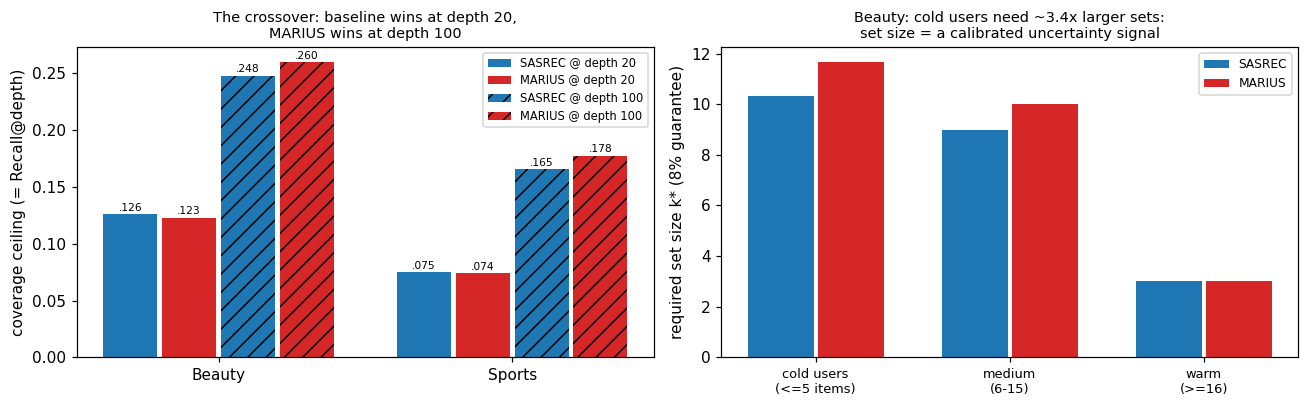

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
# (a) ceilings at depth 20 vs 100: the crossover
width = 0.2
xs = np.arange(2)  # datasets
for j, (depth, dirname, colname) in enumerate([(20, 'conformal', 'ceiling_recall20_all'),
                                                (100, 'conformal_d100', 'ceiling_recall_all')]):
    for i, m in enumerate(['sasrec', 'marius']):
        vals = []
        for cat in CATS:
            df = pd.read_csv(EXT / dirname / f'split_conformal_{cat}.csv')
            vals.append(df[df.model == m][colname].mean())
        off = (j * 2 + i - 1.5) * width
        hatch = '' if depth == 20 else '//'
        axes[0].bar(xs + off, vals, width * 0.92, color=COL[m], hatch=hatch,
                    label=f'{m.upper()} @ depth {depth}')
        for xi, v in zip(xs, vals):
            axes[0].text(xi + off, v + 0.003, f'{v:.3f}'[1:], ha='center', fontsize=7)
axes[0].set_xticks(xs); axes[0].set_xticklabels([SHORT[c] for c in CATS])
axes[0].set_ylabel('coverage ceiling (= Recall@depth)')
axes[0].set_title('The crossover: baseline wins at depth 20,\nMARIUS wins at depth 100', fontsize=9.5)
axes[0].legend(fontsize=7.5)
# (b) Mondrian: set size as an uncertainty meter (Beauty, c=0.08, depth 20)
mo = pd.read_csv(EXT / 'conformal' / 'mondrian_Beauty.csv')
mo = mo[(mo.target_coverage == 0.08) & mo.achievable]
buckets = ['hist<=5', 'hist6-15', 'hist>=16']
xb = np.arange(3)
for i, m in enumerate(['sasrec', 'marius']):
    g = mo[mo.model == m].groupby('bucket')['k_star'].mean().reindex(buckets)
    axes[1].bar(xb + (i - 0.5) * 0.36, g.values, 0.34, label=m.upper(), color=COL[m])
axes[1].set_xticks(xb)
axes[1].set_xticklabels(['cold users\n(<=5 items)', 'medium\n(6-15)', 'warm\n(>=16)'], fontsize=8.5)
axes[1].set_ylabel('required set size k* (8% guarantee)')
axes[1].set_title('Beauty: cold users need ~3.4x larger sets:\nset size = a calibrated uncertainty signal', fontsize=9.5)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. FUSE: the architectural null (and why it helps the story)

Could MARIUS's gap be an architecture bug? It squashes each item's 4 code embeddings into one history token with a plain sum, a habit inherited from audio models that is blind to which digit mattered. We built a subclass (zero edits to the authors' code) with level-aware alternatives, all exactly equal to the baseline at initialization, and trained them: 3 seeds, Beauty.

**Result: accuracy is unchanged.** The sum-fusion is NOT the bottleneck. This clean null rules out the architecture prong and concentrates all evidence on decoding. Two bonuses: our torch-free selftest mathematically PROVED one planned arm (additive per-level biases) collapses to the baseline before any GPU time was spent on it; and the cheapest arm (per-level gains) mildly improves every beyond-accuracy metric at zero accuracy cost.

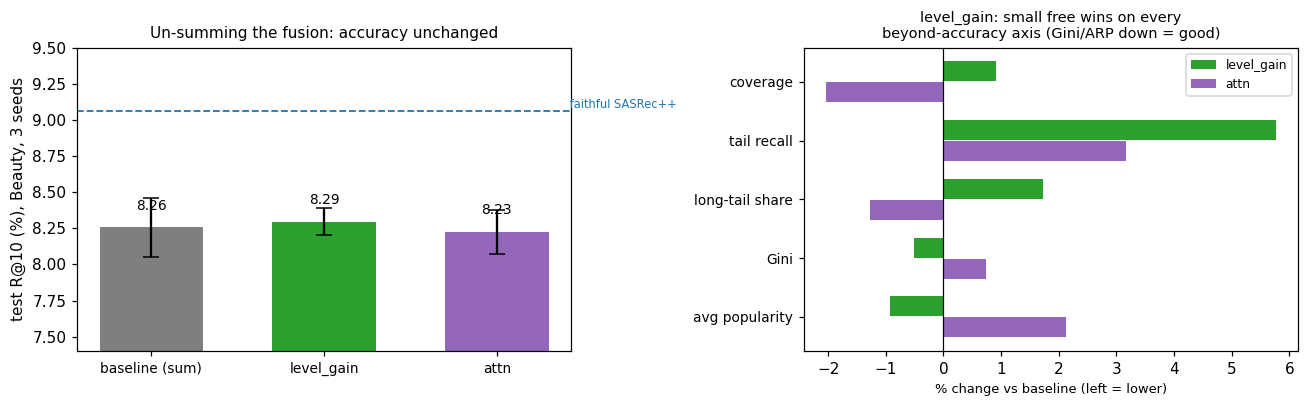

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
# (a) R@10 with error bars
arms = [('baseline (sum)', EXT / 'baseline_scur1217' / 'marius_beauty_5seed_full_scores.jsonl', '#7f7f7f'),
        ('level_gain', EXT / 'fuse' / 'level_gain' / 'marius_beauty_5seed_full_scores.jsonl', '#2ca02c'),
        ('attn', EXT / 'fuse' / 'attn' / 'marius_beauty_5seed_full_scores.jsonl', '#9467bd')]
for xi, (label, path, c) in enumerate(arms):
    mean, std, n = jsonl_r10(path)
    axes[0].bar(xi, mean, 0.6, yerr=std, capsize=5, color=c)
    axes[0].text(xi, mean + 0.12, f'{mean:.2f}', ha='center', fontsize=9)
axes[0].axhline(9.06, color=COL['sasrec'], ls='--', lw=1.2)
axes[0].text(2.4, 9.06, ' faithful SASRec++', fontsize=7.5, va='bottom', color=COL['sasrec'])
axes[0].set_xticks(range(3)); axes[0].set_xticklabels([a[0] for a in arms], fontsize=9)
axes[0].set_ylabel('test R@10 (%), Beauty, 3 seeds')
axes[0].set_ylim(7.4, 9.5)
axes[0].set_title('Un-summing the fusion: accuracy unchanged', fontsize=10)
# (b) beyond-accuracy relative change vs baseline (k=10)
base = pd.read_csv(EXT / 'beyond_accuracy_Beauty.csv')
b = base[(base.model == 'marius') & (base.k == 10)].iloc[0]
metrics = [('coverage_mean', 'coverage'), ('tail_recall_mean', 'tail recall'),
           ('aplt_mean', 'long-tail share'), ('gini_mean', 'Gini'), ('arp_mean', 'avg popularity')]
good_up = {'coverage_mean': 1, 'tail_recall_mean': 1, 'aplt_mean': 1, 'gini_mean': -1, 'arp_mean': -1}
y = np.arange(len(metrics))
for i, arm in enumerate(['level_gain', 'attn']):
    df = pd.read_csv(EXT / 'fuse' / f'beyond_accuracy_Beauty_{arm}.csv')
    row = df[df.k == 10].iloc[0]
    rel = [100 * (row[mc] - b[mc]) / b[mc] for mc, _ in metrics]
    axes[1].barh(y + (i - 0.5) * 0.36, rel, 0.34, label=arm,
                 color=['#2ca02c', '#9467bd'][i])
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_yticks(y); axes[1].set_yticklabels([lbl for _, lbl in metrics], fontsize=9)
axes[1].set_xlabel('% change vs baseline (left = lower)', fontsize=8.5)
axes[1].set_title('level_gain: small free wins on every\nbeyond-accuracy axis (Gini/ARP down = good)', fontsize=9.5)
axes[1].invert_yaxis(); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8. Synthesis: the paper this adds up to

Every pilot result points at one coherent story:

> **Catalog collapse in semantic-ID generative recommenders: diagnosis and decode-time remedies.**

| Piece | Evidence | Status |
|---|---|---|
| The phenomenon | diversity profile inverts with dataset density; Sports coverage 0.39 vs 0.74 | done, 3 seeds |
| The stakes | 22-23% of training demand invisible to the generative model | done |
| The mechanism | step-2 pruning of weak code-pair families; sibling competition (r = -0.62) | done, robust across 2 codebooks |
| The locus | NOT architecture (FUSE null); decoding (depth-100 crossover: MARIUS's deep candidates beat the baseline) | done |
| Generic remedies | MBR = tunable accuracy-vs-reach dial (+32% tail recall on Sports); conformal = guarantees + uncertainty meter | done |
| The method gap | a mechanism-TARGETED decoder: re-inject exploration at depth step 2 (pair level), aiming to dominate the MBR Pareto | next |
| Optional scale axis | prediction: more siblings per fixed 256-way prefix at Amazon-2023 scale = worse collapse even as accuracy rises | untested (~4-8k SBU) |

Everything above ran on well under 5,000 of our 400,000 SBU. The reproduction is merged on `main`; all extension work, dumps, and results live on the `stanislaw` branch with every number regenerable from committed code (see CODE_OVERVIEW.md for the full provenance map).